# Strip coordinate picker

Goal of this notebook: plot all the proseg cells on chip coordinates so I can
see where the tissue sits, decide where to draw a strip that spans the
epidermis through to the deep dermis, and read the (x_min, x_max, y_min, y_max)
off the axes.

Once I have the numbers, I paste them into `configs/strip_01.yaml` and then
run `python pipeline/01_subset_strip.py --config configs/strip_01.yaml`.

This notebook is exploration only. No outputs get saved from here.

In [1]:
from pathlib import Path
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np

PROSEG_H5AD = Path('/Users/chobani/keloid_analysis/outputs/proseg_full_raw.h5ad')

a = ad.read_h5ad(PROSEG_H5AD)
print(f'cells : {a.n_obs:,}')
print(f'genes : {a.n_vars:,}')
print(f'x range: {a.obsm["spatial"][:,0].min():.0f} to {a.obsm["spatial"][:,0].max():.0f}')
print(f'y range: {a.obsm["spatial"][:,1].min():.0f} to {a.obsm["spatial"][:,1].max():.0f}')

cells : 33,926
genes : 32,858
x range: 4030 to 12284
y range: 3868 to 14116


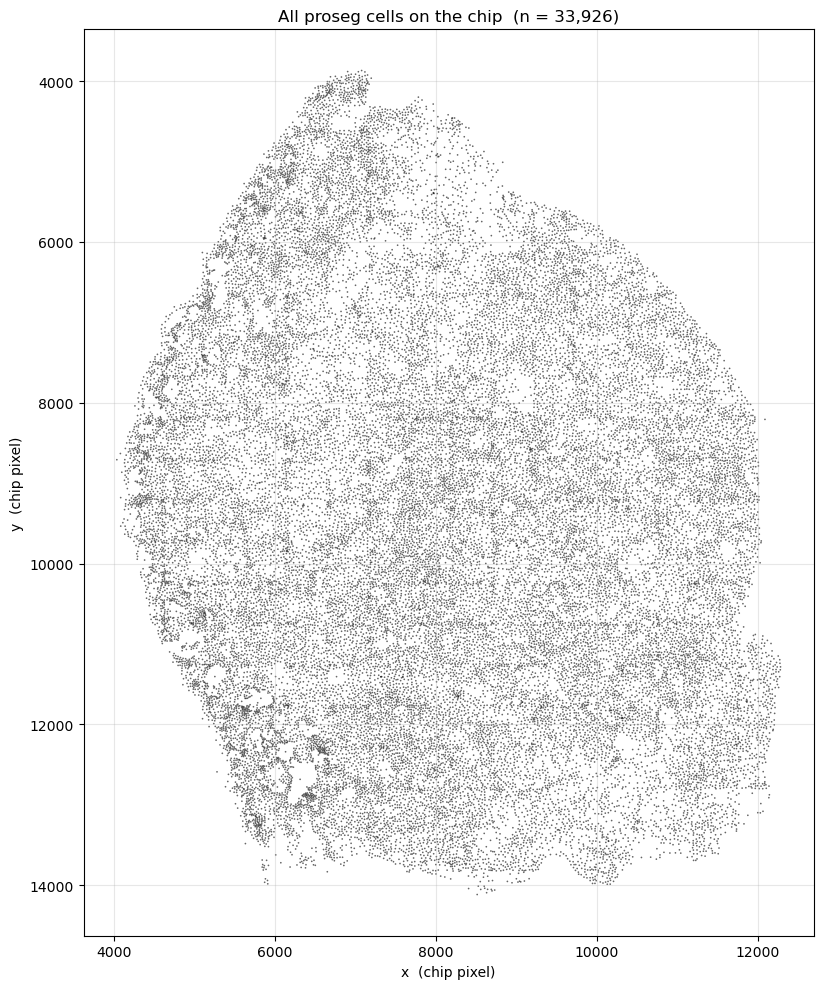

In [3]:
# Plot every proseg cell as a small dot at its chip coordinate.
# Colour is uniform so we can see tissue shape and density.

fig, ax = plt.subplots(figsize=(11, 10))
ax.scatter(a.obsm['spatial'][:, 0],
           a.obsm['spatial'][:, 1],
           s=1.5, c='black', alpha=0.6, edgecolors='none')
ax.invert_yaxis()                # image-style orientation (y grows downward)
ax.set_aspect('equal')
ax.set_xlabel('x  (chip pixel)')
ax.set_ylabel('y  (chip pixel)')
ax.set_title(f'All proseg cells on the chip  (n = {a.n_obs:,})')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## How to pick a strip from this plot

1. Look at the figure above.
2. Identify the tissue edges (where the cell density drops to zero). The
   epidermis sits along the outer boundary of the tissue.
3. Decide where to draw a long thin rectangle that runs perpendicular to the
   epidermal edge so it spans from the edge into the deep dermis.
4. Read approximate `x_min, x_max, y_min, y_max` off the axes.
5. Paste those numbers into `configs/strip_01.yaml`.

The next cell lets me preview a candidate strip before committing to it.

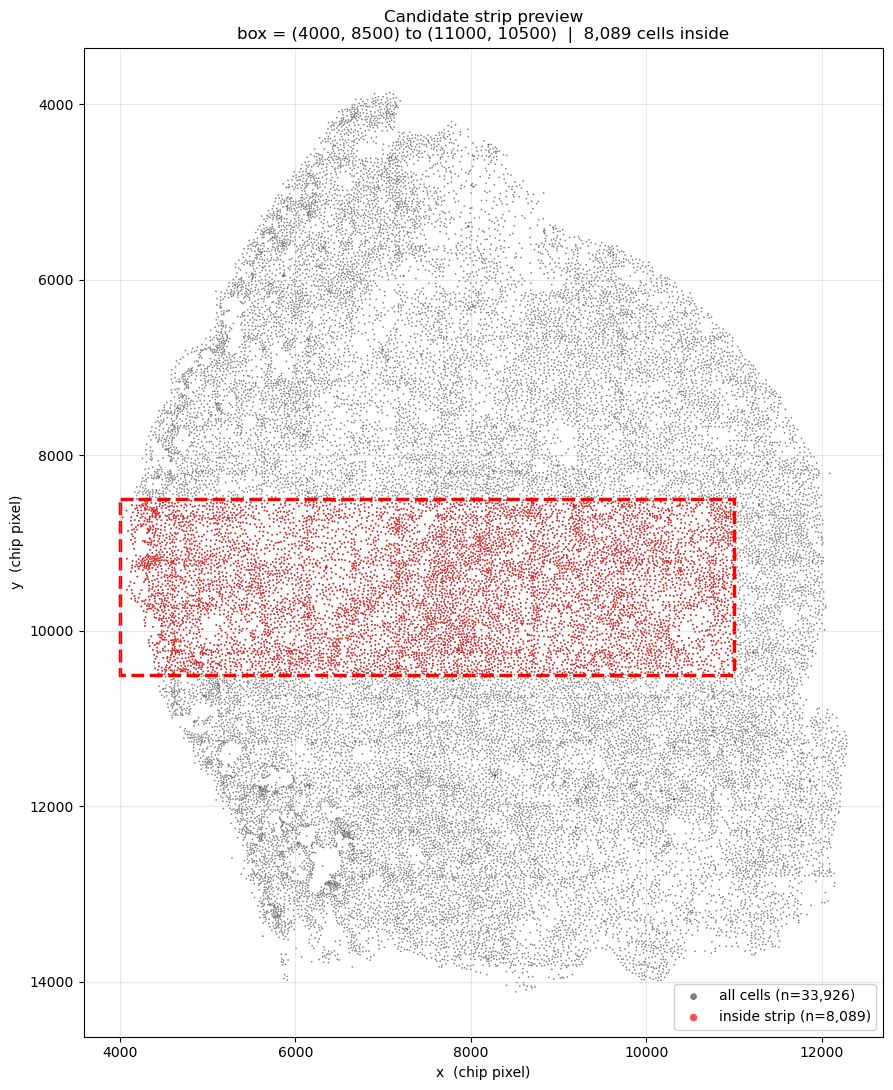


Cells inside the box: 8,089
Cells outside       : 25,837

Paste these into configs/strip_01.yaml under strip_coords:
  x_min: 4000
  x_max: 11000
  y_min: 8500
  y_max: 10500


In [6]:
# Validate a candidate strip: shows the WHOLE chip (all cells visible)
# with the candidate strip overlaid as a red rectangle.
# Edit the four numbers below, re-run to preview.

from matplotlib.patches import Rectangle

candidate = dict(x_min=4000, x_max=11000, y_min=8500, y_max=10500)

xy = a.obsm['spatial']
in_strip = (
    (xy[:, 0] >= candidate['x_min']) & (xy[:, 0] <= candidate['x_max']) &
    (xy[:, 1] >= candidate['y_min']) & (xy[:, 1] <= candidate['y_max'])
)
n_in  = int(in_strip.sum())
n_out = int((~in_strip).sum())

fig, ax = plt.subplots(figsize=(11, 11))

# All cells in dark grey so the chip is fully visible
ax.scatter(xy[:, 0], xy[:, 1],
           s=1.5, c='black', alpha=0.5, edgecolors='none',
           label=f'all cells (n={a.n_obs:,})')

# Cells INSIDE the strip highlighted in red on top
ax.scatter(xy[in_strip, 0], xy[in_strip, 1],
           s=1.8, c='red', alpha=0.7, edgecolors='none',
           label=f'inside strip (n={n_in:,})')

# Strip rectangle outline
ax.add_patch(Rectangle(
    (candidate['x_min'], candidate['y_min']),
    candidate['x_max'] - candidate['x_min'],
    candidate['y_max'] - candidate['y_min'],
    fill=False, edgecolor='red', lw=2.5, linestyle='--',
))

ax.invert_yaxis()
ax.set_aspect('equal')
ax.set_xlabel('x  (chip pixel)')
ax.set_ylabel('y  (chip pixel)')
ax.set_title(f'Candidate strip preview\n'
             f'box = ({candidate["x_min"]}, {candidate["y_min"]}) '
             f'to ({candidate["x_max"]}, {candidate["y_max"]})  |  '
             f'{n_in:,} cells inside')
ax.legend(loc='lower right', markerscale=4, framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nCells inside the box: {n_in:,}')
print(f'Cells outside       : {n_out:,}')
print(f'\nPaste these into configs/strip_01.yaml under strip_coords:')
for k, v in candidate.items():
    print(f'  {k}: {v}')

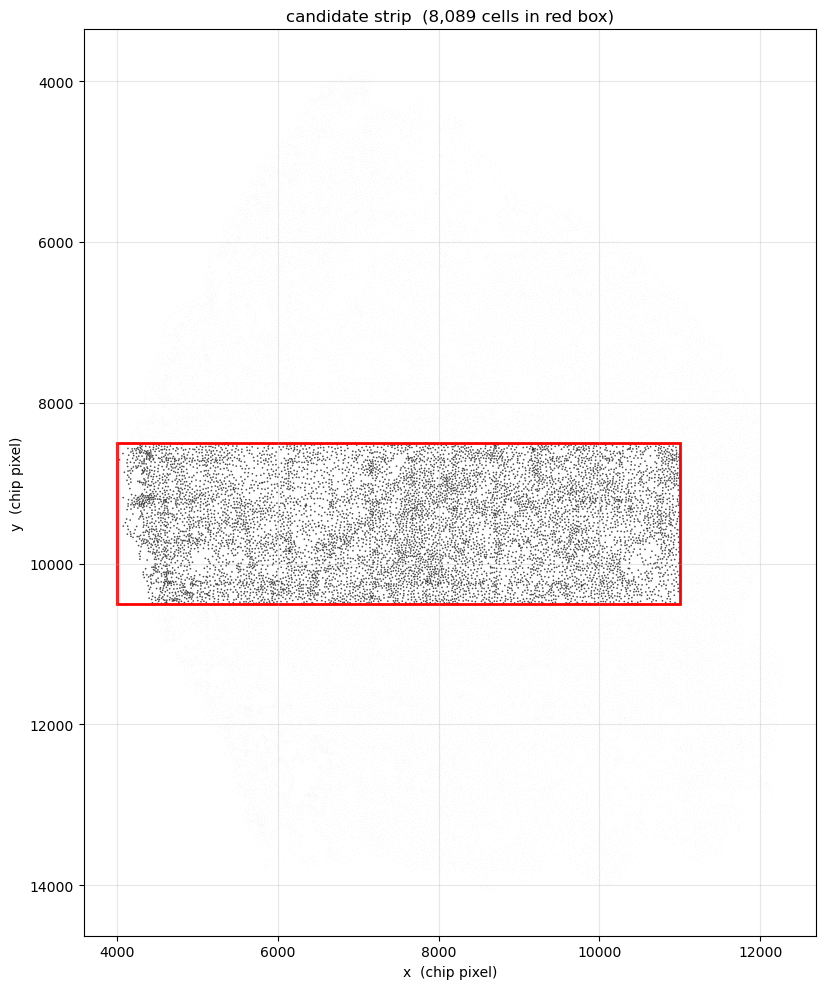

cells inside candidate strip: 8,089
paste into strip_01.yaml -> strip_coords:
  x_min: 4000
  x_max: 11000
  y_min: 8500
  y_max: 10500


In [5]:
# Preview a candidate strip: edit the four numbers below, re-run this cell.
# A red rectangle is overlaid on the same chip plot to show what I am picking.

candidate = dict(x_min=4000, x_max=11000, y_min=8500, y_max=10500)

xy = a.obsm['spatial']
in_strip = (
    (xy[:, 0] >= candidate['x_min']) & (xy[:, 0] <= candidate['x_max']) &
    (xy[:, 1] >= candidate['y_min']) & (xy[:, 1] <= candidate['y_max'])
)
n_in = int(in_strip.sum())

fig, ax = plt.subplots(figsize=(11, 10))
ax.scatter(xy[~in_strip, 0], xy[~in_strip, 1],
           s=0.3, c='lightgrey', alpha=0.4, edgecolors='none')
ax.scatter(xy[in_strip, 0], xy[in_strip, 1],
           s=1.5, c='black', alpha=0.7, edgecolors='none')
from matplotlib.patches import Rectangle
ax.add_patch(Rectangle(
    (candidate['x_min'], candidate['y_min']),
    candidate['x_max'] - candidate['x_min'],
    candidate['y_max'] - candidate['y_min'],
    fill=False, edgecolor='red', lw=2,
))
ax.invert_yaxis(); ax.set_aspect('equal')
ax.set_xlabel('x  (chip pixel)'); ax.set_ylabel('y  (chip pixel)')
ax.set_title(f'candidate strip  ({n_in:,} cells in red box)')
ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
print(f'cells inside candidate strip: {n_in:,}')
print(f'paste into strip_01.yaml -> strip_coords:')
for k, v in candidate.items():
    print(f'  {k}: {v}')